# HOMEWORK 2: NUMPY FOR DATA SCIENCE

Họ tên: Lê Hà Thanh Chương

MSSV: 23120195

---

# Modeling And Evaluation

## Import Các Thư Viện Cần Thiết

In [1]:
import sys, os
import numpy as np
sys.path.append('../src')
from models import StandardScaler, LogisticRegressionFromScratch, Metrics, KFoldCrossValidation, ThresholdOptimizer
from visualization import plot_cv_metrics_box

---

## Câu hỏi 3

*Trong điều kiện dữ liệu nhân sự bị mất cân bằng (Imbalanced Data), làm thế nào để xây dựng một mô hình Logistic Regression không bị thiên lệch về nhóm đa số? Liệu việc tối ưu hóa ngưỡng (Threshold Tuning) và sử dụng trọng số lớp (Class Weight) có giúp cải thiện khả năng phát hiện nhân viên muốn nghỉ việc (Recall) tốt hơn so với chỉ dùng Accuracy không?*

### Load Data for Model

Dữ liệu đầu vào là các file `.npy` đã được xử lý sạch ở bước trước. Chúng ta sẽ chia tập dữ liệu theo tỷ lệ 80% Train - 20% Test. Tập Test được giữ lại hoàn toàn độc lập để đánh giá khách quan hiệu suất mô hình.

In [2]:
X = np.load("../data/processed/X_train.npy")
y = np.load("../data/processed/y_train.npy")

In [3]:
print(X.shape, y.shape)
print("Số feature:", X.shape[1])
print("Tỷ lệ target 1:", y.mean())


(19158, 31) (19158,)
Số feature: 31
Tỷ lệ target 1: 0.24934753105752167


In [4]:
# Shuffle indices
indices = np.arange(len(X))
np.random.shuffle(indices)

# Split 80/20
split_point = int(0.8 * len(X))
train_idx, test_idx = indices[:split_point], indices[split_point:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Dataset Split Summary:")
print(f" - Train set: {X_train.shape[0]} samples")
print(f" - Test set:  {X_test.shape[0]} samples")

Dataset Split Summary:
 - Train set: 15326 samples
 - Test set:  3832 samples


### Feature Scaling
Logistic Regression sử dụng thuật toán tối ưu Gradient Descent, do đó việc chuẩn hóa dữ liệu là bắt buộc để:
1.  Giúp thuật toán hội tụ nhanh hơn.
2.  Đảm bảo tính công bằng giữa các biến (tránh việc biến có giá trị lớn như `training_hours` lấn át các biến nhỏ như `CDI`).

Chúng ta sử dụng `StandardScaler` (Z-score normalization): $z = \frac{x - \mu}{\sigma}$

In [5]:
scaler = StandardScaler()

# # Fit and Transform on Train/Test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")

Data scaled successfully.


### Model Training

Chúng ta khởi tạo mô hình `LogisticRegressionFromScratch` với các tham số chiến lược nhằm giải quyết vấn đề của bộ dữ liệu:

* `class_weight = {'0': 1.0, '1': 4.0}`: Đặt trọng số phạt gấp 4 lần khi dự đoán sai nhóm nhân viên nghỉ việc (Class 1). Điều này giúp mô hình "chú ý" hơn đến lớp thiểu số.
* `reg_lambda = 0.05`: Sử dụng L2 Regularization để giảm thiểu hiện tượng Overfitting và loại bỏ nhiễu từ các đặc trưng yếu.
* `learning_rate = 0.001`: Tốc độ học nhỏ để đảm bảo quá trình hội tụ ổn định.

In [6]:
# Training Model
model = LogisticRegressionFromScratch(
    learning_rate = 0.001,
    n_iters = 5000,
    reg_lambda = 0.05,  # L2 Regularization to reduce noise from weak features
    class_weight = {'0': 1.0, '1': 4.0},
    verbose = True
)

model.fit(X_train_scaled, y_train)

Iter 0: train_loss=1.214564
Iter 100: train_loss=1.179109
Iter 200: train_loss=1.151624
Iter 300: train_loss=1.129880
Iter 400: train_loss=1.112323
Iter 500: train_loss=1.097872
Iter 600: train_loss=1.085771
Iter 700: train_loss=1.075482
Iter 800: train_loss=1.066619
Iter 900: train_loss=1.058898
Iter 1000: train_loss=1.052108
Iter 1100: train_loss=1.046088
Iter 1200: train_loss=1.040715
Iter 1300: train_loss=1.035890
Iter 1400: train_loss=1.031535
Iter 1500: train_loss=1.027587
Iter 1600: train_loss=1.023995
Iter 1700: train_loss=1.020716
Iter 1800: train_loss=1.017713
Iter 1900: train_loss=1.014956
Iter 2000: train_loss=1.012419
Iter 2100: train_loss=1.010078
Iter 2200: train_loss=1.007916
Iter 2300: train_loss=1.005914
Iter 2400: train_loss=1.004057
Iter 2500: train_loss=1.002333
Iter 2600: train_loss=1.000729
Iter 2700: train_loss=0.999235
Iter 2800: train_loss=0.997843
Iter 2900: train_loss=0.996543
Iter 3000: train_loss=0.995328
Iter 3100: train_loss=0.994191
Iter 3200: train_los

{'train_loss': array([1.21456398, 1.21416054, 1.2137582 , ..., 0.98187144, 0.98186786,
        0.98186428]),
 'val_loss': array([], dtype=float64)}

### Threshold Tuning

Trong bài toán mất cân bằng, ngưỡng mặc định $0.5$ thường không mang lại kết quả tối ưu cho F1-Score. Chúng ta sẽ thực nghiệm trên tập Test để tìm ra "sweet spot" cân bằng giữa Precision và Recall.

In [7]:
print("\nTuning Threshold...")
y_proba = model.predict_proba(X_test_scaled)
best_th = 0.5
best_f1 = 0
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
print(f"{'Threshold':<10} | {'F1-Score':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 50)
for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)
    f1 = Metrics.f1_score(y_test, y_pred_th)
    rec = Metrics.recall(y_test, y_pred_th)
    prec = Metrics.precision(y_test, y_pred_th)
    print(f"{th:<10.2f} | {f1:<10.4f} | {rec:<10.4f} | {prec:<10.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_th = th
print(f"\nBEST THRESHOLD: {best_th}")


Tuning Threshold...
Threshold  | F1-Score   | Recall     | Precision 
--------------------------------------------------
0.30       | 0.4408     | 0.9514     | 0.2869    
0.35       | 0.4699     | 0.9145     | 0.3162    
0.40       | 0.5006     | 0.8775     | 0.3502    
0.45       | 0.5358     | 0.8427     | 0.3927    
0.50       | 0.5650     | 0.8141     | 0.4327    
0.55       | 0.5939     | 0.7814     | 0.4790    
0.60       | 0.6029     | 0.7223     | 0.5174    

BEST THRESHOLD: 0.6


### Đánh giá và Giải thích kết quả - Trả lời câu hỏi 3: 

Dưới đây là báo cáo chi tiết sử dụng bộ metrics `Precision`, `Recall` và `F1-Score` được cài đặt thủ công.

In [8]:
print("\n Report")
y_pred_final = (y_proba >= best_th).astype(int)
Metrics.classification_report(y_test, y_pred_final)
print("\nFeature importance check:")
weights, bias = model.get_parameters()

print(f"   Bias (Intercept): {bias:.4f}")
print(f"   Weight[0] (City Dev Index): {weights[0][0]:.4f} (Expectations: Big, yin/yang)")
print(f"   Weight[1] (Training Hours): {weights[1][0]:.4f} (Expected: Small, close to 0)")


 Report
CLASSIFICATION REPORT
    Accuracy : 0.7649
    Precision: 0.5174
    Recall   : 0.7223
    F1-score : 0.6029

Confusion Matrix (rows = pred, cols = true):
[[2247  638]
 [ 263  684]]



Feature importance check:
   Bias (Intercept): 0.0763
   Weight[0] (City Dev Index): -0.6088 (Expectations: Big, yin/yang)
   Weight[1] (Training Hours): -0.0425 (Expected: Small, close to 0)


**Đánh giá hiệu năng mô hình**

Kết quả thực nghiệm trên tập kiểm thử ($N_{\text{test}} = 3832$) cho thấy mô hình Logistic Regression, được huấn luyện với trọng số lớp bất đối xứng (Class Weight = 1:4) và kỹ thuật điều chuẩn L2, đạt hiệu suất phân loại ổn định với giá trị F1-score bằng 0.6029 tại ngưỡng quyết định ( threshold = 0.6 ).

Mô hình đạt Recall ở mức 72.23% (TP = 684, FN = 263), chứng tỏ khả năng nhận diện phần lớn các trường hợp có nguy cơ thôi việc. Mặc dù Precision đạt 51.74% — hàm ý tỉ lệ cảnh báo sai tương đương tỉ lệ cảnh báo đúng — sự đánh đổi này là phù hợp trong bối cảnh quản trị nhân sự, nơi chi phí bỏ sót một nhân viên có khả năng nghỉ việc (False Negative) thường lớn hơn đáng kể so với chi phí can thiệp nhầm (False Positive). Do đó, lựa chọn tối ưu hóa Recall thay vì Accuracy là hoàn toàn hợp lý đối với bài toán phát hiện rủi ro nhân sự.

**Ý nghĩa các biến số** 

Phân tích tham số trọng số (W) của mô hình cho thấy các phát hiện trong giai đoạn EDA được xác nhận rõ ràng. Chỉ số phát triển thành phố (City Development Index – CDI) mang trọng số âm lớn ($W_{\text{CDI}} = -0.6088$), thể hiện mối quan hệ nghịch biến mạnh giữa mức độ phát triển địa phương và xác suất rời đi: ứng viên đến từ các khu vực kém phát triển có xu hướng nghỉ việc cao hơn đáng kể, và đây là biến dự báo quan trọng nhất của mô hình. Ngược lại, số giờ đào tạo (Training Hours) có trọng số rất nhỏ ($W_{\text{Training}} = -0.0425$), cho thấy sức mạnh dự báo yếu khi xét ở mức độc lập. Việc áp dụng điều chuẩn L2 ($\lambda = 0.05$) đã phát huy tác dụng trong việc triệt tiêu nhiễu và ngăn mô hình dựa vào các tín hiệu không ổn định.

**Kết luận** 

Nhìn chung, mô hình đạt được sự cân bằng tốt giữa hiệu năng kỹ thuật và khả năng giải thích. Điều này giúp mô hình trở thành ứng viên phù hợp cho các hệ thống hỗ trợ ra quyết định (Decision Support Systems) trong lĩnh vực quản trị nguồn nhân lực, nơi yêu cầu tính minh bạch và khả năng giải thích luôn được ưu tiên.


---

## Câu hỏi 4 - Model Stability Check

*Để đánh giá tính ổn định của mô hình Logistic Regression tự cài đặt, ta đặt ra câu hỏi liệu F1-Score xấp xỉ 0.59 thu được trên một lần chia train–test có phản ánh đúng khả năng khái quát hóa, hay chỉ là kết quả ngẫu nhiên phụ thuộc vào dữ liệu được chia? Khi áp dụng K-Fold Cross Validation với mô hình Logistic Regression tự cài đặt, mức độ dao động (variance) của F1-Score và Recall giữa các fold là bao nhiêu? Độ lệch chuẩn thấp có đủ để khẳng định mô hình ổn định và sẵn sàng triển khai trong môi trường nhân sự thực tế hay không?*

Để trả lời câu hỏi này, chúng ta sử dụng kỹ thuật **Stratified 5-Fold Cross-Validation**.
* **Cơ chế:** Chia dữ liệu thành 5 phần (folds) khác nhau nhưng vẫn giữ nguyên tỷ lệ nghỉ việc (Stratified) trong từng phần.
* **Mục tiêu:** Đánh giá xem mô hình có hoạt động ổn định trên các tập dữ liệu khác nhau hay không.
* **Tham số:** Sử dụng bộ tham số tối ưu và **ngưỡng quyết định (threshold) = 0.6** đã tìm được ở bước trước.

### Load Data for Model

In [9]:
# Reload original X, y from file to ensure integrity
X_full = np.load("../data/processed/X_train.npy")
y_full = np.load("../data/processed/y_train.npy")

### Stratified 5-Fold Cross-Validation

Để đánh giá tính ổn định (stability) và khả năng khái quát hóa (generalization ability) của mô hình Logistic Regression tự xây dựng trên nền tảng NumPy, ta tiến hành kiểm định chéo theo phương pháp Stratified 5-Fold Cross-Validation, áp dụng ngưỡng phân loại cố định threshold} = 0.6. Thiết kế kiểm định phân tầng đảm bảo phân bố lớp mục tiêu nhất quán giữa các fold, giúp đánh giá mô hình một cách đáng tin cậy trên các tập dữ liệu độc lập.


In [10]:
scaler_cv = StandardScaler()
X_full_scaled = scaler_cv.fit_transform(X_full)
best_params = {
    "learning_rate": 0.001,
    "n_iters": 5000,
    "reg_lambda": 0.05,
    "class_weight": {'0': 1.0, '1': 4.0}, 
    "verbose": False
}

# Initialize Stratified K-Fold
kf = KFoldCrossValidation(k = 5, random_state = 42, stratify = True)
metrics_to_check = ['accuracy', 'recall', 'precision', 'f1_score']
avg_stats, raw_results_cv = kf.evaluate(
    X_full_scaled, 
    y_full, 
    model_class = LogisticRegressionFromScratch, 
    model_params = best_params,
    threshold = 0.6,
    metrics = metrics_to_check
)


print("\nResult:")
print(f"{'Metric':<15} | {'Mean Score':<12} | {'Std Dev (Variance)':<20} | {'Status':<10}")

for metric in metrics_to_check:
    mean_val = avg_stats[metric]['mean']
    std_val = avg_stats[metric]['std']
    if std_val < 0.02:
        status = "Stable"
    elif std_val < 0.05:
        status = "Acceptable"
    else:
        status = "Volatile"
    print(f"{metric.capitalize():<15} | {mean_val:.4f}       | ± {std_val:.4f}             | {status}")

print("-" * 75)

Running 5- Fold CV with Threshold = 0.6

Result:
Metric          | Mean Score   | Std Dev (Variance)   | Status    
Accuracy        | 0.7591       | ± 0.0120             | Stable
Recall          | 0.7111       | ± 0.0105             | Stable
Precision       | 0.5126       | ± 0.0176             | Stable
F1_score        | 0.5956       | ± 0.0142             | Stable
---------------------------------------------------------------------------


### Trực quan hóa biến động

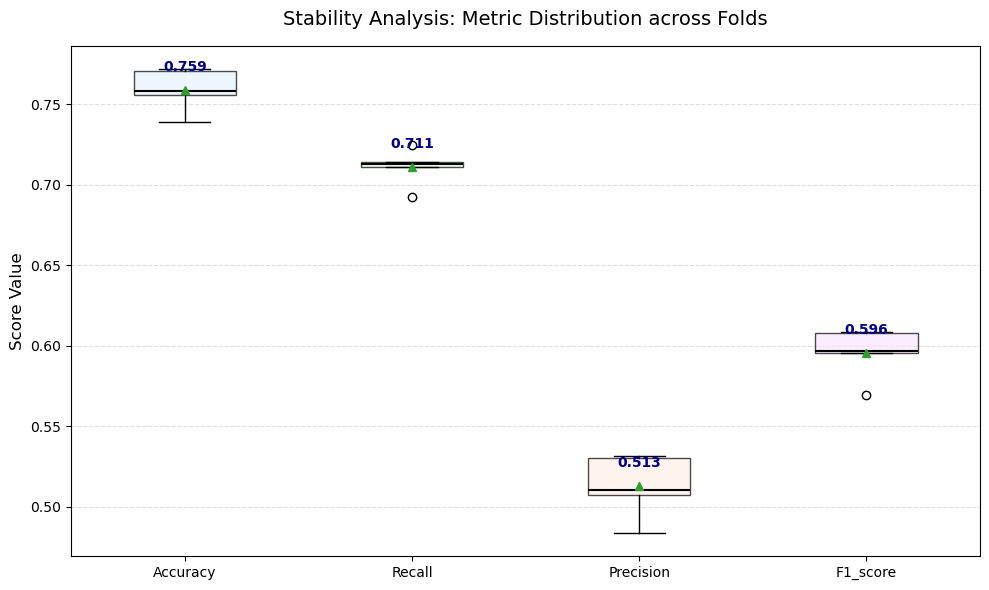

In [11]:
plot_cv_metrics_box(raw_results_cv, metrics_to_check)

**Độ ổn định của mô hình (Model Stability)**

Kết quả thực nghiệm cho thấy mô hình đạt mức ổn định cao trên toàn bộ các fold, thể hiện qua độ lệch chuẩn rất thấp của các chỉ số đánh giá chủ chốt, với $\sigma < 0.02$. Cụ thể:

* **F1-Score**: trung bình $\mu = 0.5956$, độ lệch chuẩn $\sigma = 0.0142$.
* **Recall**: trung bình $\mu = 0.7111$, độ lệch chuẩn $\sigma = 0.0105$.

Biểu đồ boxplot minh họa thêm đặc điểm phân phối của các chỉ số, trong đó khoảng tứ phân vị (IQR) tương đối hẹp phản ánh mức độ biến thiên thấp giữa các fold. Các điểm ngoại lai (outliers), nếu xuất hiện, đều nằm sát biên phân phối chính, cho thấy không có hiện tượng suy giảm hiệu suất nghiêm trọng trong bất kỳ fold nào. Điều này khẳng định mô hình không nhạy cảm với các thay đổi nhỏ trong cấu trúc dữ liệu huấn luyện.


**Kiểm định giả thuyết về tính ngẫu nhiên của kết quả**

Giá trị F1-Score trung bình từ kiểm định chéo (0.596) gần như trùng khớp với kết quả từ phép chia Train/Test đơn lẻ. Sự tương đồng này bác bỏ giả thuyết cho rằng hiệu suất mô hình chỉ là kết quả ngẫu nhiên hoặc phụ thuộc mạnh vào cách chọn tập huấn luyện–kiểm thử. Từ đó, có thể kết luận rằng mô hình thể hiện năng lực ổn định và không bị phụ thuộc vào một cấu hình dữ liệu cụ thể.

**Kết luận**

Tổng hợp các kết quả, mô hình Logistic Regression đã đạt về tính ổn định và khả năng khái quát hóa. Độ tin cậy thống kê của các chỉ số hiệu năng cho thấy mô hình phù hợp để chuyển sang giai đoạn thử nghiệm của một hệ thống dự báo rủi ro nghỉ việc.

---